# Inferencia y Métricas con Canary-1B-v2
Este notebook evalúa cuantitativamente el modelo `nvidia/canary-1b-v2` usando una versión ligera del dataset `PolyAI/minds14` (5 audios) y genera métricas de **WER** y **CER** junto con visualizaciones estilizadas.

In [1]:
import os, io, string, warnings, logging
import numpy as np
import torch, librosa, soundfile as sf, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from jiwer import wer, cer
from datasets import load_dataset, Audio
import nemo.collections.asr as nemo_asr
import nemo.utils

# Configuración de Logging para reducir verbosidad
warnings.filterwarnings("ignore")
nemo.utils.logging.set_verbosity(nemo.utils.logging.ERROR)
logging.getLogger("nemo_logging").setLevel(logging.ERROR)

def clean_text(text):
    if not isinstance(text, str): text = str(text)
    text = text.lower()
    text = text.translate(str.maketrans("", "", string.punctuation))
    return " ".join(text.split())


/home/garayco/master_project/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[NeMo W 2026-03-25 13:22:52 nemo_logging:405] Megatron num_microbatches_calculator not found, using Apex version.
OneLogger: Setting error_handling_strategy to DISABLE_QUIETLY_AND_REPORT_METRIC_ERROR for rank (rank=0) with OneLogger disabled. To override: explicitly set error_handling_strategy parameter.
No exporters were provided. This means that no telemetry data will be collected.


## 1. Preparación de Audios de Prueba
Descargamos audios en español de HuggingFace y los preparamos a 16kHz.

In [3]:
print("Descargando audios de prueba de facebook/multilingual_librispeech (spanish)...")
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    dataset_it = load_dataset("facebook/multilingual_librispeech", "spanish", split="test", streaming=True)
    dataset_it = dataset_it.cast_column("audio", Audio(decode=False))
    samples = list(dataset_it.take(10))

test_data = []
os.makedirs("test_audios", exist_ok=True)

for i, sample in enumerate(samples):
    audio_path = f"test_audios/audio_{i}.wav"
    audio_array, orig_sr = sf.read(io.BytesIO(sample["audio"]["bytes"]))
    if audio_array.ndim > 1: audio_array = audio_array.mean(axis=1)
    audio_array = audio_array.astype(np.float32)
    if orig_sr != 16000: audio_array = librosa.resample(y=audio_array, orig_sr=orig_sr, target_sr=16000)
    sf.write(audio_path, audio_array, 16000)
    test_data.append({
        'audio_path': audio_path,
        'ground_truth': sample["transcript"],
        'source_lang': 'es', 'target_lang': 'es', 'task': 'asr', 'pnc': 'no'
    })
print(f"✅ {len(test_data)} audios de MLS listos en 'test_audios/'.")


Descargando audios de prueba de facebook/multilingual_librispeech (spanish)...
✅ 10 audios de MLS listos en 'test_audios/'.


## 2. Carga del Modelo
Cargamos el modelo Canary-1B-v2.

In [4]:
model = nemo_asr.models.ASRModel.from_pretrained("nvidia/canary-1b-v2")
print("Modelo cargado")

Error getting class at nemo.collections.asr.modules.transformer.get_nemo_transformer: Located non-class of type 'function' while loading 'nemo.collections.asr.modules.transformer.get_nemo_transformer'


Modelo cargado


## 3. Inferencia y Cálculo de Métricas

In [5]:
results = []
for item in test_data:
    pred = model.transcribe(verbose=False, audio=[item['audio_path']], batch_size=1,
                            task=item['task'], source_lang=item['source_lang'],
                            target_lang=item['target_lang'], pnc=item['pnc'])
    pred_str = pred[0] if isinstance(pred, list) else pred
    if not isinstance(pred_str, str):
        pred_str = getattr(pred_str, 'text', str(pred_str))
    
    clean_pred = clean_text(pred_str)
    r_wer = wer(clean_text(item['ground_truth']), clean_pred)
    r_cer = cer(clean_text(item['ground_truth']), clean_pred)
    
    results.append({
        'Audio': os.path.basename(item['audio_path']).replace('.wav', ''),
        'Ground Truth': item['ground_truth'],
        'Raw Prediction': pred_str,
        'Prediction': clean_pred, 
        'WER': round(r_wer, 4),
        'CER': round(r_cer, 4)
    })

df_results = pd.DataFrame(results)
display(df_results)


[NeMo W 2026-03-25 01:23:55 nemo_logging:405] The following configuration keys are ignored by Lhotse dataloader: trim_silence,enable_chunking
[NeMo W 2026-03-25 01:23:55 nemo_logging:405] You are using a non-tarred dataset and requested tokenization during data sampling (pretokenize=True). This will cause the tokenization to happen in the main (GPU) process,possibly impacting the training speed if your tokenizer is very large.If the impact is noticable, set pretokenize=False in dataloader config.(note: that will disable token-per-second filtering and 2D bucketing features)


[NeMo W 2026-03-25 01:24:00 nemo_logging:405] The following configuration keys are ignored by Lhotse dataloader: trim_silence,enable_chunking
[NeMo W 2026-03-25 01:24:00 nemo_logging:405] You are using a non-tarred dataset and requested tokenization during data sampling (pretokenize=True). This will cause the tokenization to happen in the main (GPU) process,possibly impacting the training speed if your tokenizer is very large.If the impact is noticable, set pretokenize=False in dataloader config.(note: that will disable token-per-second filtering and 2D bucketing features)
[NeMo W 2026-03-25 01:24:01 nemo_logging:405] The following configuration keys are ignored by Lhotse dataloader: trim_silence,enable_chunking
[NeMo W 2026-03-25 01:24:01 nemo_logging:405] You are using a non-tarred dataset and requested tokenization during data sampling (pretokenize=True). This will cause the tokenization to happen in the main (GPU) process,possibly impacting the training speed if your tokenizer is v

,Audio,Ground Truth,Raw Prediction,Prediction,WER,CER
0,audio_0,y las almas buscando algún alivio se revuelven...,"y las almas, buscando algún alivio, se revuelv...",y las almas buscando algún alivio se revuelven...,0.0000,0.0000
1,audio_1,cuando calla el dolor se oye a la muerte las a...,"Cuando calla el dolor, se oye a la muerte las ...",cuando calla el dolor se oye a la muerte las a...,0.0000,0.0000
2,audio_2,echar fuera la vida y acallar las domésticas c...,echar fuera la vida y acallar las domésticas c...,echar fuera la vida y acallar las domésticas c...,0.0732,0.0181
3,audio_3,el vivir con el hombre pobre bestia te ha dado...,"El vivir con el hombre, pobre bestia, te ha da...",el vivir con el hombre pobre bestia te ha dado...,0.0000,0.0000
4,audio_4,no sabe lo que busca y tú para él mi alma sólo...,"No sabe lo que busca, y tú para él, mi alma, s...",no sabe lo que busca y tú para él mi alma solo...,0.0435,0.0090
5,audio_5,como todas las penas aunque tantas son una sol...,"Como todas las penas, aunque tantas, son una s...",como todas las penas aunque tantas son una sol...,0.0000,0.0000
6,audio_6,pero allí no tendremos en torno de nuestra alm...,"Pero allí, ¿no tendremos en torno de nuestra a...",pero allí ¿no tendremos en torno de nuestra al...,0.0263,0.0056
7,audio_7,tú has muerto en mansedumbre tú con dulzura en...,"Tú has muerto en mansedumbre, tú con dulzura, ...",tú has muerto en mansedumbre tú con dulzura en...,0.0500,0.0097
8,audio_8,el que gime junto a la tumba de su dios de su ...,"El que gime junto a la tumba de su Dios, de su...",el que gime junto a la tumba de su dios de su ...,0.0000,0.0000
9,audio_9,allá en el otro mundo tu alma pobre perro no h...,"Allá, en el otro mundo, tu alma, pobre perro, ...",allá en el otro mundo tu alma pobre perro no h...,0.0000,0.0000


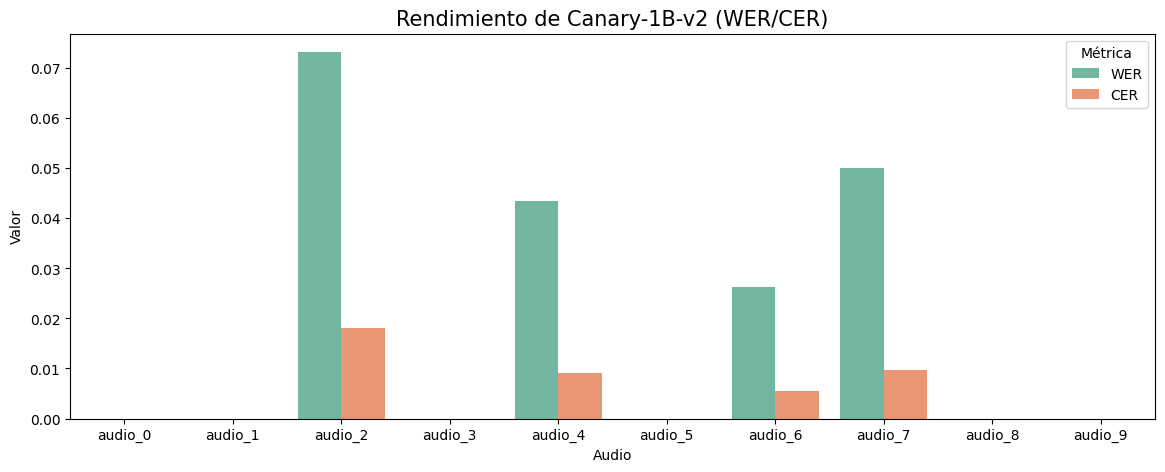

In [6]:
if not df_results.empty:
    df_melted = df_results.melt(id_vars=["Audio"], value_vars=["WER", "CER"], var_name="Métrica", value_name="Valor")
    plt.figure(figsize=(14, 5))
    sns.barplot(data=df_melted, x="Audio", y="Valor", hue="Métrica", palette="Set2")
    plt.title("Rendimiento de Canary-1B-v2 (WER/CER)", fontsize=15)
    plt.show()

In [7]:
for idx in [2, 7]:
    row = df_results[df_results['Audio'] == f'audio_{idx}'].iloc[0]
    print(f"{'='*80}")
    print(f"  Audio         : test_audios/audio_{idx}.wav")
    print(f"  Ground truth  : {row['Ground Truth']}")
    print(f"  Raw Prediction: {row['Raw Prediction']}")
    print(f"  Predicción    : {row['Prediction']}")
    print(f"  WER={row['WER']:.4f}  CER={row['CER']:.4f}")
print(f"{'='*80}")


  Audio         : test_audios/audio_2.wav
  Ground truth  : echar fuera la vida y acallar las domésticas cuestiones con el huero fragor de las políticas no hagas caso á los hombres que se juntan y gritan hojas sus gritos son que el viento lleva mientras en silencio su dolor radica
  Raw Prediction: echar fuera la vida y acallar las domésticas cuestiones con el güero fragor de las políticas. No hagas caso a los hombres que se juntan y gritan. Ojas sus gritos son que el viento lleva, mientras en silencio su dolor radica.
  Predicción    : echar fuera la vida y acallar las domésticas cuestiones con el güero fragor de las políticas no hagas caso a los hombres que se juntan y gritan ojas sus gritos son que el viento lleva mientras en silencio su dolor radica
  WER=0.0732  CER=0.0181
  Audio         : test_audios/audio_7.wav
  Ground truth  : tú has muerto en mansedumbre tú con dulzura entregándote á mí en la suprema sumisión de la vida pero él
  Raw Prediction: Tú has muerto en mansedumbre,

In [8]:
avg_wer = df_results["WER"].mean()
avg_cer = df_results["CER"].mean()
n_perfect = (df_results["WER"] == 0).sum()

print("=" * 60)
print("  ANÁLISIS CUANTITATIVO")
print("=" * 60)
print(f"  WER Promedio : {avg_wer:.2%}")
print(f"  CER Promedio : {avg_cer:.2%}")
print(f"  Transcripciones exactas (WER=0): {n_perfect} / {len(df_results)}")
print("=" * 60)

errores = df_results[df_results["WER"] > 0][["Audio", "WER", "CER"]]
print("\n  Audios con errores:")
print(errores.to_string(index=False))
print()
print(f"  El modelo alcanzó transcripción exacta en el {n_perfect/len(df_results):.0%} de los casos.")



  ANÁLISIS CUANTITATIVO
  WER Promedio : 1.93%
  CER Promedio : 0.42%
  Transcripciones exactas (WER=0): 6 / 10

  Audios con errores:
  Audio    WER    CER
audio_2 0.0732 0.0181
audio_4 0.0435 0.0090
audio_6 0.0263 0.0056
audio_7 0.0500 0.0097

  El modelo alcanzó transcripción exacta en el 60% de los casos.
